In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PHASE 0: Data Loading

In [3]:
df = pd.read_csv(r'D:\Hustle\Chennai-PG\Data\raw\chennai_pg_dataset.csv') # this is raw dataset, DO NOT touch this
df_clean = pd.read_csv(r'D:\Hustle\Chennai-PG\Data\raw\chennai_pg_dataset.csv') # this is for pahse 3 and phase 4, instaead of do phase 4 with raw dataset i use this
df.head()

,id,title,latitude,longitude,locality,address,gender,available_for,transit_score,lifestyle_score,...,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,gate_closing_time,smoking_allowed,guardian_required,nonveg_allowed
0,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
1,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
2,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
3,8a9fae838be6a66a018be7e0229327a9,PG for Boys in Perungalathur,12.905105,80.095660,Perungalathur,", Gateway Office Parks Rd near Perungalathur P...",MALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
4,8a9fb38499ce0d630199ce1448fd00e1,PG for Boys in Old Perungalathur,12.918673,80.081292,Shanthi Nagar,Parvathi Nagar near ( GANAPATHY MEN'S HOSTEL ...,MALE,Both,5.9,9.1,...,False,False,False,False,False,False,NaN,False,False,False


1. What is my TARGET variable? 
    - the target variable is `rent`
2. Is this regression or classification?
    - going to use regression, cuz the target is continous
3. What does one ROW represent? 
    - one PG listing (one PG's room)
4. How was this data collected? 
    - the data collected from web scraping
5. What does a MISSING VALUE mean in this domain?

----------------------------------------------------------------------------------
# PHASE 1: SANITY CHECK

- Shape and structure
- Check the datatypes
- Missing Values
- Duplicates
- Unique value count for (categorical)
- Basic stats

In [26]:
# 1.1 shape and structure + dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1783 entries, 0 to 1782
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1783 non-null   str    
 1   title               1783 non-null   str    
 2   latitude            1783 non-null   float64
 3   longitude           1783 non-null   float64
 4   locality            1783 non-null   str    
 5   address             1783 non-null   str    
 6   gender              1783 non-null   str    
 7   available_for       1783 non-null   str    
 8   transit_score       883 non-null    float64
 9   lifestyle_score     883 non-null    float64
 10  occupancy           1759 non-null   str    
 11  rent                1759 non-null   float64
 12  deposit             1759 non-null   float64
 13  attached_bathroom   1759 non-null   object 
 14  food_included       1783 non-null   bool   
 15  breakfast           1783 non-null   bool   
 16  lunch            

## Key observation
    
- our dataset has missing values
- some of the columns have True/False as `object` dtype, so need to change into `bool` data type
    

In [10]:
df['room_bedding'].unique()

array([True, False, nan], dtype=object)

In [4]:
# 1.2 Missing values
def missing_info(df):
    missing_info = pd.DataFrame({
        'missing count': df.isna().sum(),
        'missing %': (df.isna().mean() * 100).round(2),
        'Data type': df.dtypes,
    })

    missing_info = missing_info[missing_info['missing count'] > 0]
    missing_info.sort_values('missing %', ascending = False)
    return missing_info

In [28]:
missing_info(df)

,missing count,missing %,Data type
transit_score,900,50.48,float64
lifestyle_score,900,50.48,float64
occupancy,24,1.35,str
rent,24,1.35,float64
deposit,24,1.35,float64
attached_bathroom,24,1.35,object
mess,834,46.78,object
wifi,830,46.55,object
laundry,806,45.20,object
power_backup,830,46.55,object


## Key observation from the missing values analysis

### SCORES
- i can see that the scores (transit & lifestylr) are missing around 50%
- so we need to understand why the API did not returned the values?
- ok, as of my obervation about the API, it indicates that the API did not returned these scores for the listing. The exact reason is unknown (e.g., score unavailable or not computed).

### Amenties (wifi, laundry, etc...)

- and these amenities are missing around 45%, we should not drop or impute without validation
- so after validation: 
	by comparing actual JSON response from the API with actual PG (in Website) (eg. analyzed the wifi - True/false/Nan)

- so coclusion the True means = available
        - True means = Pg owner provided the info, as available
        - False means = Pg owner provided the info, as unavailable
        - Nan means = the provider does not provided the actual amenities
        whether the PG has Wifi or not

Assumption:
Listings with an empty amenitiesMap provide no amenity information.
For modeling, missing amenity values are treated as False,
assuming unlisted amenities are unavailable.

### And for some columns has ~1% missing values

- i can see that the target variable also has missing values
- so we can drop these column which have ~1% of missinng values
- it is safe, cuz its just ~1% in our dataset

### and the one coloumn has nearly ~80%+ missing values

- and mainly the `gate_closing_time` lable does'nt seems to be a helpful label
- so i should drop it, without hesitation!

-------------------------------------------------------------------------
## Conlcusion

### scores

Imputation strategy:
- Missingness is preserved using binary indicator columns:
    - transit_score_missing
    - lifestyle_score_missing
- Missing scores are imputed using the median score within the same locality, assuming properties in the same locality have similar accessibility characteristics.
- If an entire locality has missing scores, the remaining NaN values are filled using the global median.

### amenties (wifi, laundry, etc)

- fill False

### droping columns

- columns which have ~1% missing values
- columns which has over ~80% missing values


In [5]:
# 1.3 Duplicates
def isDuplicates(df: pd.DataFrame):
    print(f'Total duplicates: {df.duplicated().sum()}')
    return df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(20)

In [14]:
isDuplicates(df)

Total duplicates: 162


,id,title,latitude,longitude,locality,address,gender,available_for,transit_score,lifestyle_score,...,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,gate_closing_time,smoking_allowed,guardian_required,nonveg_allowed
830,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,False,True,False,False,True,True,11:00 PM,True,True,False
833,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,False,True,False,False,True,True,11:00 PM,True,True,False
832,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,11:00 PM,True,True,False
835,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,11:00 PM,True,True,False
831,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,False,True,False,False,True,True,11:00 PM,True,True,False
834,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,False,True,False,False,True,True,11:00 PM,True,True,False
1013,8a9f84449233260d019233676f89127e,PG for Girls in Tharamani,12.982616,80.238006,Tharamani,"Anna Nagar, near Panchamukha Hanuman Temple, ...",FEMALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
1016,8a9f84449233260d019233676f89127e,PG for Girls in Tharamani,12.982616,80.238006,Tharamani,"Anna Nagar, near Panchamukha Hanuman Temple, ...",FEMALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
1015,8a9f84449233260d019233676f89127e,PG for Girls in Tharamani,12.982616,80.238006,Tharamani,"Anna Nagar, near Panchamukha Hanuman Temple, ...",FEMALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
1018,8a9f84449233260d019233676f89127e,PG for Girls in Tharamani,12.982616,80.238006,Tharamani,"Anna Nagar, near Panchamukha Hanuman Temple, ...",FEMALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False


### Key observation

- exact duplicates rows were found in the dataset
- these duplicates likely originated from overlapped API response or repeated listing (like the pg might listed under tambarm and perungaluthur as well, or new perungalayhur, who knows?)
- since all columns were identical, dups are detected based on `id` `occupancy` these two are the primary key
- These duplicates were removed using drop_duplicates(subset=['id', 'occupancy']), keeping the first occurrence of each unique property-room combination.

------------------------------------------------------------------------
### Conclusion

removes rows which are identical based on these two pairs `id` `occupancy`

```py
df_clean = df.drop_duplicates(subset=['id', 'occupancy'])
```

In [13]:
# 1.4 Unique valu counts (categorical)
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].nunique()} unique -> {df[col].unique()[:10]}')

id: 657 unique -> <StringArray>
['8aa9ba0d9ef7b08b019ef7beaaeb030e', '8a9fae838be6a66a018be7e0229327a9',
 '8a9fb38499ce0d630199ce1448fd00e1', '8aa98e6a9c1c4dca019c1cc70bf621a8',
 '8aa98e979b82e1a4019b83d99c297a01', '8a9f9182844bc06501844c39248d6b15',
 'ff808181547b7f2801547f8dfa492a85', '8a9fa98495832f000195836bfe450c9d',
 '8aa9aa7e9c64d498019c65163c521ee1', '8a9fae85971a0e6d01971a5203a7105b']
Length: 10, dtype: str
title: 181 unique -> <StringArray>
['PG for Boys in Anbu Homoeopathy And Acupuncture Clinic',
                           'PG for Boys in Perungalathur',
                       'PG for Boys in Old Perungalathur',
                         'PG for Boys in Shollinganallur',
                       'PG for Boys in New Perungalathur',
                          'PG for Boys in Perungalathur,',
                          'PG for Boys in West Tambaram ',
                            'PG for Boys in Third Street',
                        'PG for Boys in Otteri Extension',
              

C:\Users\Dinesh\AppData\Local\Temp\ipykernel_5348\2567202304.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


### KEy observation

- `id` uniquesly identifies each property, its an identifier column and this wont help in modeling
- `title` it doesnt contain necessary infos, should be droped
- `locality` contains 36 unique categories and is expexted to influence rent, so encode
- `address` not needed 
- `gender` 3 categories, easy to encode
- `available_for` again 3 categories, looks clean
- `occupancy` 4 categories and Nan also exist other than 4 (there are 24 rows, so drop it)
- `amenites` can encode this
- `parking` could later encode as 
    - no parking (nan)
    - bike
    - car
    - both
- `gate_closing_time` it has ~80% missing values so dont bother about this, ill drop it anyway

In [15]:
# 1.5 Basic stats
df.describe(include=['int64', 'float64'])   # numeric columns


,latitude,longitude,transit_score,lifestyle_score,rent,deposit,total_bathrooms
count,1783.000000,1783.000000,883.000000,883.000000,1759.000000,1759.000000,1783.000000
mean,12.959144,80.208051,7.053001,6.934428,7207.355884,5881.930642,15.365676
std,0.048097,0.050124,2.016839,1.316050,4126.793881,9785.376485,35.519123
min,12.840608,80.040125,-10.000000,1.500000,0.000000,0.000000,0.000000
25%,12.913428,80.212143,6.400000,6.200000,6000.000000,3000.000000,0.000000
50%,12.977430,80.228473,7.600000,6.300000,7000.000000,3000.000000,0.000000
75%,12.985703,80.235708,8.200000,8.100000,8500.000000,5900.000000,12.000000
max,13.115971,80.261954,9.100000,9.600000,65000.000000,200000.000000,215.000000


In [14]:
df.describe(include=['object', 'str']) # categorical column

,id,title,locality,address,gender,available_for,occupancy,attached_bathroom,mess,wifi,...,warden,cooking_allowed,parking,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,gate_closing_time
count,1783,1783,1783,1783,1783,1783,1759,1759,949,953,...,977,950,1610,1608,1620,1595,1608,1618,1618,307
unique,657,181,36,624,3,3,4,2,2,2,...,2,2,3,2,2,2,2,2,2,24
top,8a9fd32c84898be701848a319d937c89,PG for Boys in Karapakkam,Tharamani,"Tidel park , Tharamani, Tharamani, chennai",MALE,Both,THREE,False,True,True,...,True,False,Bike,False,False,False,False,False,False,10:30 PM
freq,12,131,269,12,890,1577,546,1401,491,821,...,527,488,1406,1149,1072,1305,1199,1104,1085,68


## Data Cleaning

### TASKS:

- Change the column data-type whose values are in [True/False] as an boject
- Follow the imputation startegy based on the observation / Remove the missing values
- Encode columns, based on the observations
- dedups: drop the duplicate rows
- final checks

In [6]:
# 1. Drop duplicates first, then further cleanups. 
df_clean = df_clean.drop_duplicates(subset=['id', 'occupancy'])
isDuplicates(df_clean)

Total duplicates: 0


,id,title,latitude,longitude,locality,address,gender,available_for,transit_score,lifestyle_score,...,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,gate_closing_time,smoking_allowed,guardian_required,nonveg_allowed


In [8]:
missing_info(df_clean)

,missing count,missing %,Data type
transit_score,839,51.76,float64
lifestyle_score,839,51.76,float64
occupancy,20,1.23,str
rent,20,1.23,float64
deposit,20,1.23,float64
attached_bathroom,20,1.23,object
mess,788,48.61,object
wifi,784,48.37,object
laundry,767,47.32,object
power_backup,784,48.37,object


In [7]:
# 2. drop rows which has ~1% missing values
df_clean = df_clean.dropna(subset=['rent', 'occupancy', 'deposit', 'attached_bathroom'])

# 3. drop the useless column which has high % of missing values, in our dataset `gate_closing_time` is 80%
df_clean = df_clean.drop(columns=['gate_closing_time'])

In [8]:
# 4. imputation for transit & lifestyle scores

# create missing value flag
df_clean['transit_score_missing'] = (
    df_clean['transit_score'].isna().astype(int)
)

# fill the locality median
df_clean['transit_score'] = (
    df_clean.groupby('locality')['transit_score']
    .transform(lambda x: x.fillna(x.median()))
)

# fill with overall dataset median
# if Suppose one locality has all values missing.
df_clean['transit_score'] = (
    df_clean['transit_score']
    .fillna(df_clean['transit_score'].median())
)



In [9]:
# 5. similarly for lifestyle_score
df_clean['lifestyle_score_missing'] = (
    df['lifestyle_score'].isna().astype(int)
)

df_clean['lifestyle_score'] = (
    df_clean.groupby('locality')['lifestyle_score']
    .transform(lambda x: x.fillna(x.median()))
)

df_clean['lifestyle_score'] = (
    df_clean['lifestyle_score']
    .fillna(df_clean['lifestyle_score'].median())
)

In [16]:
missing_info(df_clean)

,missing count,missing %,Data type
mess,775,48.41,object
wifi,771,48.16,object
laundry,754,47.10,object
power_backup,771,48.16,object
refrigerator,770,48.09,object
common_tv,770,48.09,object
room_cleaning,754,47.10,object
warden,754,47.10,object
cooking_allowed,774,48.34,object
parking,159,9.93,str


In [29]:
df['room_attached_bath'].unique()

array([True, False, nan], dtype=object)

In [10]:
# 6. before imputing the amenities (wifi, mess..) i need to change the data type
# so that i can impute them as false without any issues
bool_cols = [
    'attached_bathroom', 'mess', 'wifi', 'laundry', 'power_backup', 
    'warden', 'refrigerator', 'common_tv', 'room_cleaning', 'cooking_allowed',
    'room_ac', 'room_cupboard', 'room_tv', 'room_geyser', 'room_bedding',
    'room_attached_bath',
]
df_clean[bool_cols] = df_clean[bool_cols].astype('bool')

In [11]:
# 7. now filling the amenities column with false (reason in the observation)
df_clean[bool_cols] = df_clean[bool_cols].fillna(False)

In [12]:
# 8. for parking introduce new category None for nan
df_clean['parking'] = df_clean['parking'].fillna('None')

In [37]:
df_clean.head()

,id,title,latitude,longitude,locality,address,gender,available_for,transit_score,lifestyle_score,...,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,smoking_allowed,guardian_required,nonveg_allowed,transit_score_missing,lifestyle_score_missing
0,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,True,False,0,0
1,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,True,False,0,0
2,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,True,False,0,0
3,8a9fae838be6a66a018be7e0229327a9,PG for Boys in Perungalathur,12.905105,80.095660,Perungalathur,", Gateway Office Parks Rd near Perungalathur P...",MALE,Both,6.3,4.1,...,False,False,False,False,False,False,False,False,0,0
4,8a9fb38499ce0d630199ce1448fd00e1,PG for Boys in Old Perungalathur,12.918673,80.081292,Shanthi Nagar,Parvathi Nagar near ( GANAPATHY MEN'S HOSTEL ...,MALE,Both,5.9,9.1,...,False,False,False,False,False,False,False,False,0,0


In [13]:
df_clean = df_clean.drop(columns=['id', 'title', 'address', 'total_bathrooms', 'guardian_required'])

## Encoding Decisions  Chennai PG Dataset

| Column | Dtype | Cardinality | Technique | Justification |
|---|---|---|---|---|
| `id` | str | unique per row | 🔴 drop | identifier, zero signal |
| `title` | str | high cardinality | 🔴 drop | free text, redundant with locality |
| `address` | str | unique per row | 🔴 drop | redundant with lat/lon + locality |
| `gate_closing_time` | str | ~80% missing | 🔴 drop | too sparse to be useful |
| `total_bathrooms` | float64 | 50% zeros | 🔴 drop | building-level, not room-level |
| `latitude` | float64 | continuous | 🟢 keep as-is | numeric, no transform needed |
| `longitude` | float64 | continuous | 🟢 keep as-is | numeric, no transform needed |
| `transit_score` | float64 | continuous | 🟢 keep as-is | already imputed + sentinel removed |
| `lifestyle_score` | float64 | continuous | 🟢 keep as-is | already imputed |
| 22 bool cols | bool | binary 0/1 | 🟢 cast to int | sklearn doesn't accept bool dtype |
| `*_missing` cols | int64 | binary 0/1 | 🟢 keep as-is | already encoded indicators |
| `rent`, `deposit` | float64 | continuous | 🟢 log1p transform | skew 3.72 / 11.0 → compress tail |
| `gender` | str | 3 categories | 🔵 OHE (drop=first) | nominal, no order, low cardinality |
| `available_for` | str | 3 categories | 🔵 OHE (drop=first) | nominal, no order, low cardinality |
| `occupancy` | str | 4 categories | 🔵 OHE (drop=first) | nominal, no order, low cardinality |
| `parking` | str | 4 categories | 🔵 OHE (drop=first) | nominal, no order, low cardinality |
| `locality` | str | 36 categories | 🟡 target encode | high cardinality, strong rent signal |

### Legend
🔴 drop — 🟢 no encoding needed — 🔵 one-hot encode — 🟡 target encode

And the `occupancy` OHE note — even though SINGLE < DOUBLE < THREE < FOUR looks ordinal, the rent difference between sharing types isn't uniform or linear. A SINGLE room isn't necessarily 4× the price of a FOUR-share. So OHE is still safer than label/ordinal encoding here.

In [14]:
# Encoding (cast) bool dtype columns to int (0,1)
# cast to int (0/1) - improves consistency across preprocessing and model pipelines
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [16]:
# 1. One hot encoding
OHE_column = [
    'gender', 'available_for', 'occupancy', 'parking'
]

df_clean = pd.get_dummies(
    df_clean,
    columns = OHE_column,
    drop_first= True,
    dtype='int8'
)

In [20]:
# Drop invalid zero-rent listings
df_clean = df_clean[df_clean['rent'] > 0]

In [21]:
print((df_clean['rent'] == 0).sum())

0


# PHASE 2: TARGET VARIABLE ANALYSIS

  *Understand about the target variable*   

In [22]:
df_target = df_clean['rent']
df_target.describe()

count     1474.000000
mean      7763.561058
std       3336.329339
min          1.000000
25%       6000.000000
50%       7000.000000
75%       8500.000000
max      65000.000000
Name: rent, dtype: float64

# Quick Visualization check for outliers

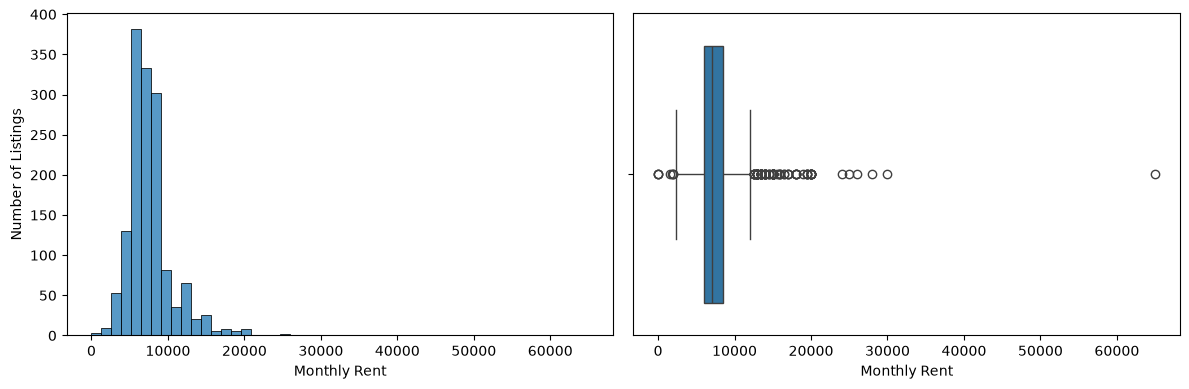

Skewness: 4.836566494107259


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sns.histplot(
    data=df_clean,
    x='rent',
    bins=50,
    ax = axes[0]
)
axes[0].set_xlabel("Monthly Rent")
axes[0].set_ylabel("Number of Listings")

# Boxplot
sns.boxplot(
    data = df_clean,
    x = 'rent',
    ax = axes[1]
)
axes[1].set_xlabel("Monthly Rent")

plt.tight_layout()
plt.show()


# Skewness
print(f"Skewness: {df_clean['rent'].skew()}")

### Key Observations:
- Rent distribution is heavily right-skewed (skewness = 3.72).
- Majority of PGs are priced between ₹6,000 and ₹10,000.
- A few listings have unusually high rents (>₹20,000), with one extreme value around ₹65,000.
- Several listings have rent = 0, (total 142 rows has 0 values)
    - confirmed: all 142 rows also have deposit=0  owner never filled pricing
    - so drop them..
- Boxplot confirms the presence of multiple upper-tail outliers.

------------------------------------------------------------------------
# PHASE 3: Feature by feature analysis

- Numeric features
- Categorical features
- Boolean / binary features

In [27]:
# 3.1 Numeric column

numeric_col = df.select_dtypes(include=['number']).columns

for col in numeric_col:
    print(f'\n{col}')
    print(f'\n{df[col].describe()}')
    print(f'\nskew: {df[col].skew():.2f}')
    print(f'-'*20)


latitude

count    1783.000000
mean       12.959144
std         0.048097
min        12.840608
25%        12.913428
50%        12.977430
75%        12.985703
max        13.115971
Name: latitude, dtype: float64

skew: 0.24
--------------------

longitude

count    1783.000000
mean       80.208051
std         0.050124
min        80.040125
25%        80.212143
50%        80.228473
75%        80.235708
max        80.261954
Name: longitude, dtype: float64

skew: -1.52
--------------------

transit_score

count    883.000000
mean       7.053001
std        2.016839
min      -10.000000
25%        6.400000
50%        7.600000
75%        8.200000
max        9.100000
Name: transit_score, dtype: float64

skew: -5.09
--------------------

lifestyle_score

count    883.000000
mean       6.934428
std        1.316050
min        1.500000
25%        6.200000
50%        6.300000
75%        8.100000
max        9.600000
Name: lifestyle_score, dtype: float64

skew: -0.57
--------------------

rent

count   

In [21]:
df['transit_score'] = df['transit_score'].replace(-10, np.nan)
# now all three states collapse to: valid score OR NaN
# re-check skew
print(df['transit_score'].skew())

-1.3166452272630254


In [22]:
missing_info(df)

,missing count,missing %,Data type
transit_score,907,50.87,float64
lifestyle_score,900,50.48,float64
occupancy,24,1.35,str
rent,24,1.35,float64
deposit,24,1.35,float64
attached_bathroom,24,1.35,object
mess,834,46.78,object
wifi,830,46.55,object
laundry,806,45.20,object
power_backup,830,46.55,object


## Observations

- in `transit_score` there is an big outlier skewd in left, and it causes the left sked dist

    Transit score is negatively skewed (skewness = -5.09) due to a single extreme value of -10. Since valid transit scores are expected to be positive, this value likely represents missing or unavailable information returned by the API.

    ### Decision:

    - Replace -10 with NaN before further analysis. (replaced and calculated skew, and now its about -1.3)


- in `deposit`, they mostly 0, in chaennai PGs deposits showing 0 is normal,
    - Deposit is highly right-skewed (skewness = 11.0). Most listings require deposits below ₹10,000, while a small number have exceptionally high deposits reaching ₹200,000.

    ### Decision:

    - These values will be retained during EDA since they may represent premium accommodations rather than data entry errors. Outlier treatment, if required, will be performed only before model training.

- the `total_bathroom` column is completly waste to have,
    because it contains many zero values and represents the total number of bathrooms in the property rather than the specific room. Similar information is already captured through `attached_bathroom` and `room_attached_bath`.

    ### Decision:

    - Remove total_bathrooms because it provides limited additional information and is less relevant for room-level rent prediction.

In [23]:
# 3.2 Categorical feature
categorical_col = df.select_dtypes(include=['object']).columns

for col in categorical_col:
    print(f'\n{col}')
    print(f'{df[col].value_counts()}')


id
id
8a9fd32c84898be701848a319d937c89    12
ff808181553aee5e01553fcc8ab2502f    12
ff808181547b7f2801547f8dfa492a85     8
ff8081815dd6701e015de0346a991f7c     8
8aa9a41c9f73b009019f73b7220c01d7     8
                                    ..
8aa9962b9f69d83a019f6a1d9e7b26d2     1
8a9fb28394406fd8019440c775991e8c     1
ff8081816c5163f7016c519132c71d0d     1
8a9fa184968fcf7601969035e35a2a53     1
8aa9b7e89b789558019b7987378b4e5e     1
Name: count, Length: 657, dtype: int64

title
title
PG for Boys in Karapakkam         131
PG for Girls in Velachery         112
PG for Boys in Tharamani           98
PG for Girls in Tharamani          96
PG for Girls in Karapakkam         93
                                 ... 
PG for Boys in Arcot                1
PG for Boys in Kodambakkam          1
PG for Girls in Kodambakkam         1
PG for Girls in Arcot               1
PG for Girls in  West Mambalam      1
Name: count, Length: 181, dtype: int64

locality
locality
Tharamani                         26

C:\Users\Dinesh\AppData\Local\Temp\ipykernel_20340\2145365474.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=['object']).columns


### Overall Observation


| Feature           | Decision       | Reason                                                |
| ----------------- | -------------- | ----------------------------------------------------- |
| id                | Drop before ML | Identifier only                                       |
| title             | Drop           | High-cardinality text                                 |
| locality          | Keep           | Important location feature                            |
| address           | Drop           | High-cardinality, redundant with locality/coordinates |
| gender            | Keep           | Useful categorical feature                            |
| available_for     | Keep           | Small number of categories                            |
| occupancy         | Keep           | Strong predictor of rent                              |
| Boolean amenities | Keep           | Useful binary features                                |
| parking           | Keep           | Small categorical feature                             |
| gate_closing_time | Drop           | >80% missing and inconsistent values                  |


In [24]:
# 3.3 Boolean / Binary features
bool_col = df.columns

for col in bool_col:
    if df[col].nunique() == 2:
        print(f'{df[col].value_counts()}')

attached_bathroom
False    1401
True      358
Name: count, dtype: int64
food_included
True     1310
False     473
Name: count, dtype: int64
breakfast
True     1283
False     500
Name: count, dtype: int64
lunch
True     1252
False     531
Name: count, dtype: int64
dinner
True     1279
False     504
Name: count, dtype: int64
mess
True     491
False    458
Name: count, dtype: int64
wifi
True     821
False    132
Name: count, dtype: int64
laundry
True     544
False    433
Name: count, dtype: int64
power_backup
False    700
True     253
Name: count, dtype: int64
refrigerator
True     643
False    311
Name: count, dtype: int64
common_tv
False    497
True     457
Name: count, dtype: int64
room_cleaning
True     775
False    202
Name: count, dtype: int64
warden
True     527
False    450
Name: count, dtype: int64
cooking_allowed
False    488
True     462
Name: count, dtype: int64
room_ac
False    1149
True      459
Name: count, dtype: int64
room_cupboard
False    1072
True      548
Name: count,

### Observation

| Category         | Observation                        | Decision                                  |
| ---------------- | ---------------------------------- | ----------------------------------------- |
| Bathroom         | Attached bathrooms are uncommon    | Keep                                      |
| Food             | Most PGs provide food and meals    | Keep; check redundancy                    |
| Common amenities | Mostly balanced                    | Keep                                      |
| Room amenities   | Premium amenities are less common  | Keep                                      |
| Smoking          | Mostly prohibited                  | Keep                                      |
| Guardian         | Mostly not required                | Keep                                      |
| Non-veg          | Extremely imbalanced (97.6% False) | Consider dropping after feature selection |

Non-veg: (edit: should drop, nearly zero variance dont help)


In [17]:
# Close the open threads
print("rent=0:", (df['rent'] == 0).sum())
print("occupancy NaN:", df['occupancy'].isna().sum())
print("transit -10:", (df['transit_score'] == -10).sum())
print("transit+lifestyle same missing rows:", 
      (df['transit_score'].isna() == df['lifestyle_score'].isna()).all()) # should be false now, cuz i filled nan (for -10, in transit)

rent=0: 142
occupancy NaN: 24
transit -10: 0
transit+lifestyle same missing rows: False


# PHASE 4: Relationship (feature vs target)

### 4.1 Numeric Features vs target

## Purpose
- measure linear relationship
- find important numeric predictors
- detect trends and outliers

In [45]:
# 1. Correlation with rent

corr = (
    df.select_dtypes(include=['number', 'bool'])
    .corr(numeric_only = True)['rent']
    .sort_values(ascending = False)
)
corr

rent                 1.000000
deposit              0.451658
longitude            0.099334
food_included        0.069091
breakfast            0.055465
dinner               0.052834
lunch                0.052054
lifestyle_score      0.038740
nonveg_allowed      -0.007773
smoking_allowed     -0.011352
latitude            -0.025556
transit_score       -0.038408
total_bathrooms     -0.062148
guardian_required   -0.073996
Name: rent, dtype: float64

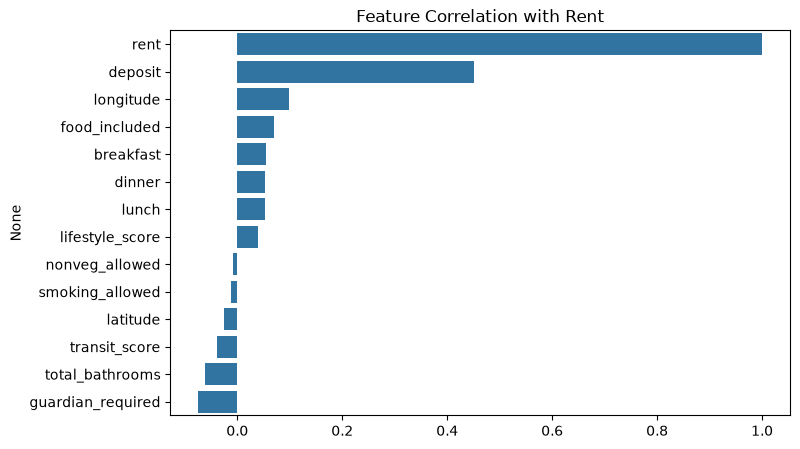

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=corr.values,
    y=corr.index
)

plt.title("Feature Correlation with Rent")
plt.show()

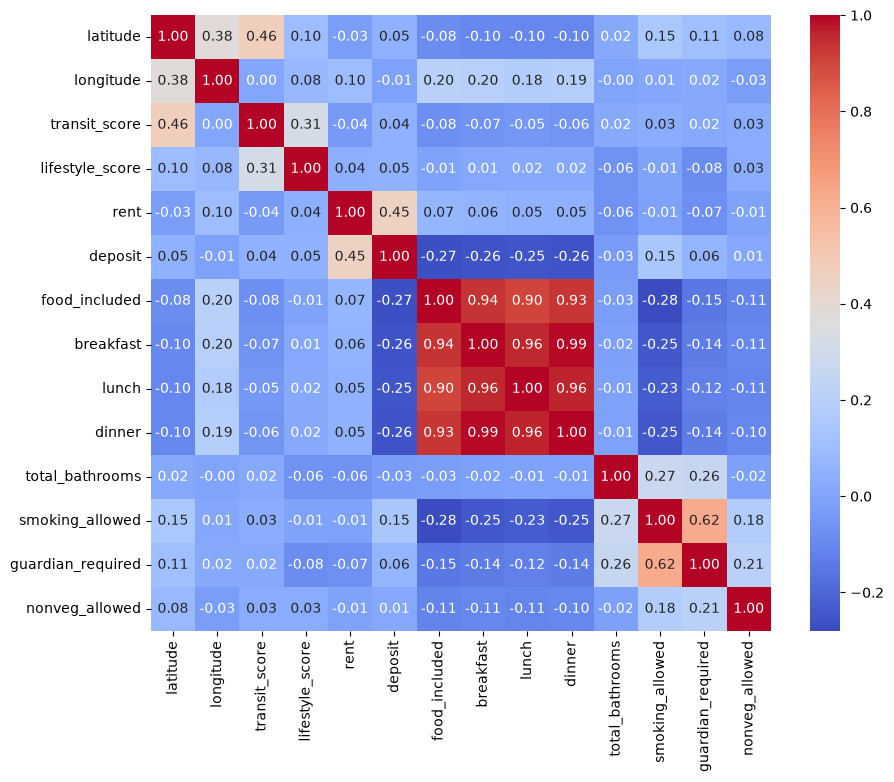

In [42]:
plt.figure(figsize=(10, 8))

corr = df.select_dtypes(include=['number', 'bool']).corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.show()

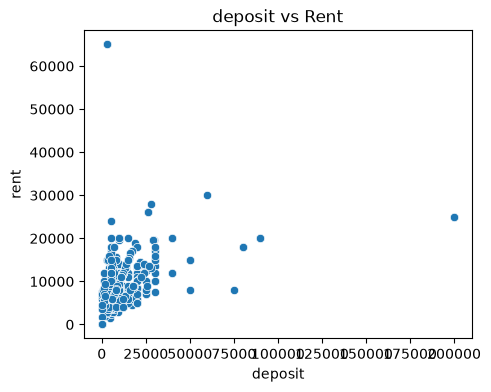

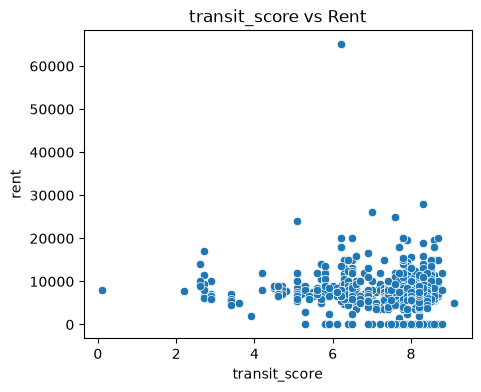

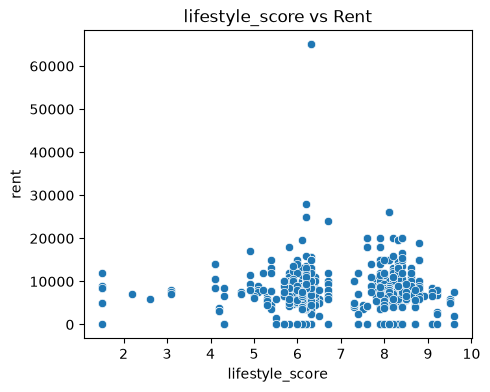

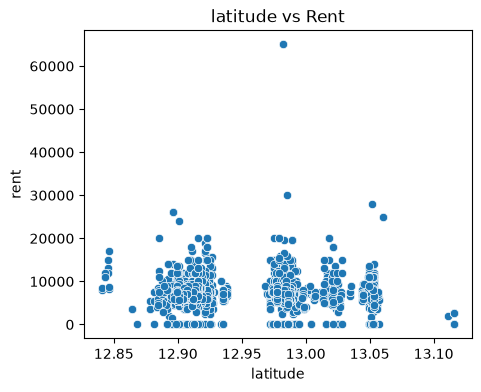

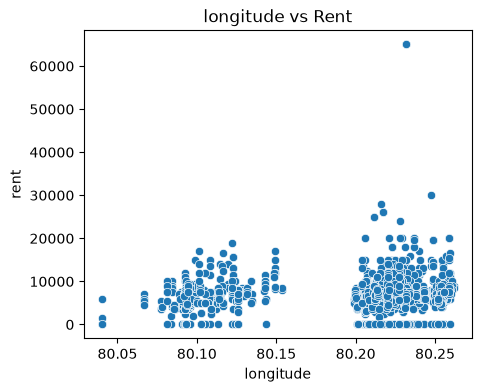

In [39]:
numeric_cols = [
    "deposit",
    "transit_score",
    "lifestyle_score",
    "latitude",
    "longitude"
]

for col in numeric_cols:
    plt.figure(figsize=(5,4))
    sns.scatterplot(data=df, x=col, y="rent")
    plt.title(f"{col} vs Rent")
    plt.show()

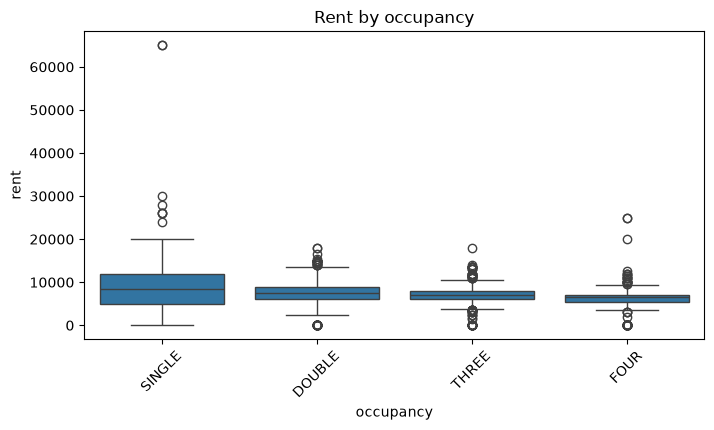

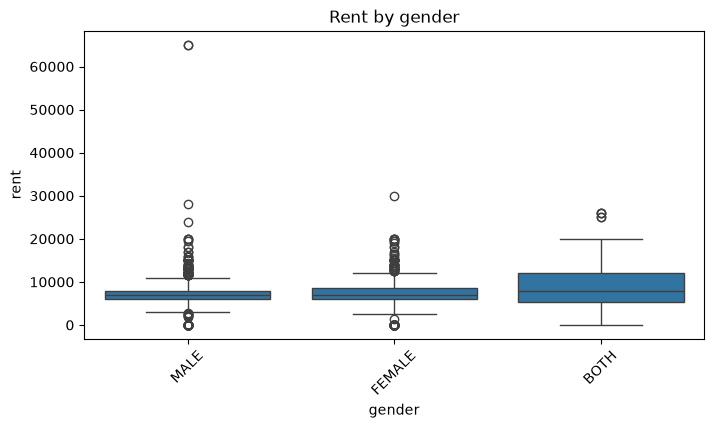

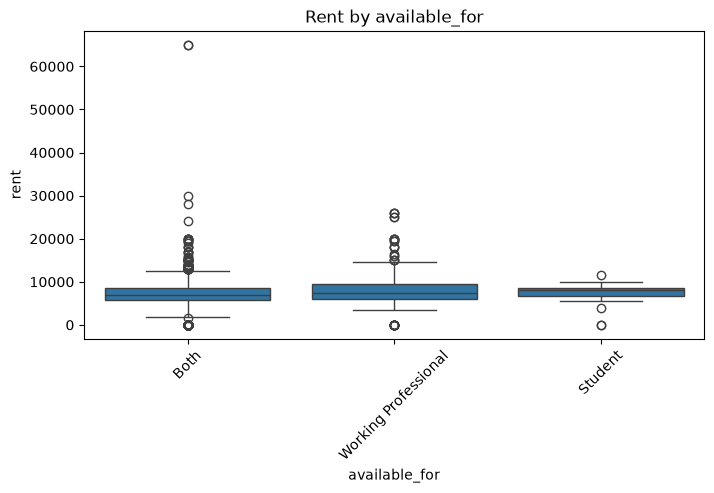

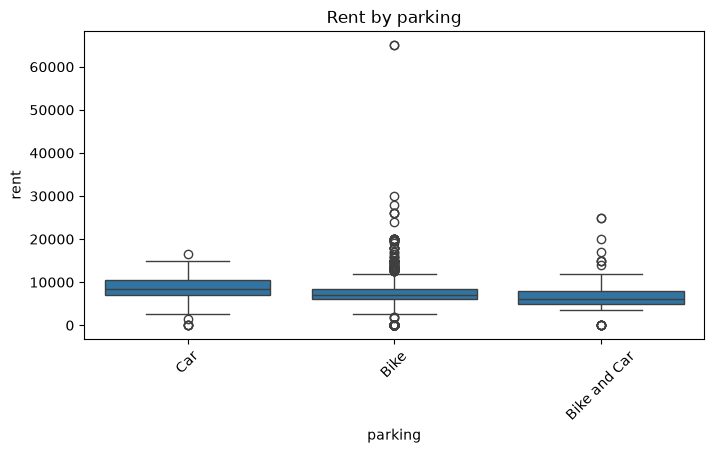

In [47]:
cat_cols = [
    "occupancy",
    "gender",
    "available_for",
    "parking"
]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col, y="rent")
    plt.xticks(rotation=45)
    plt.title(f"Rent by {col}")
    plt.show()

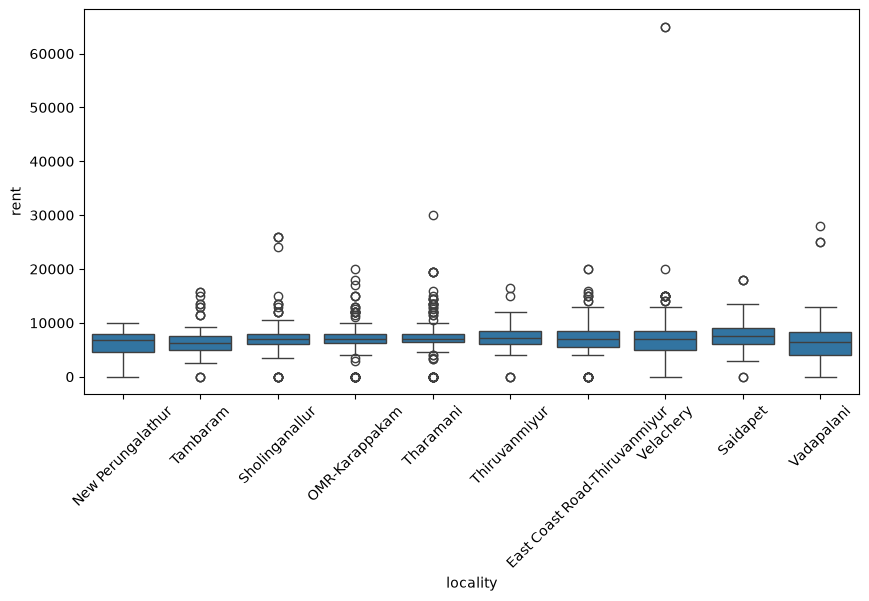

In [48]:
top_locality = (
    df["locality"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[df["locality"].isin(top_locality)],
    x="locality",
    y="rent"
)

plt.xticks(rotation=45)
plt.show()

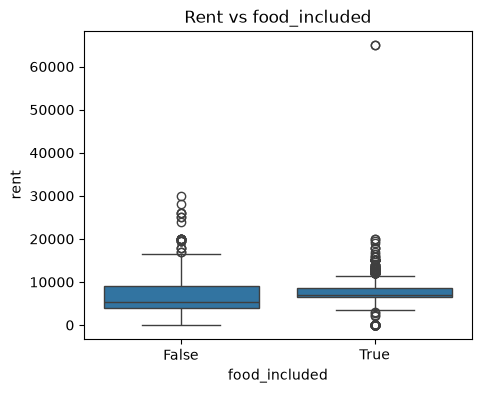

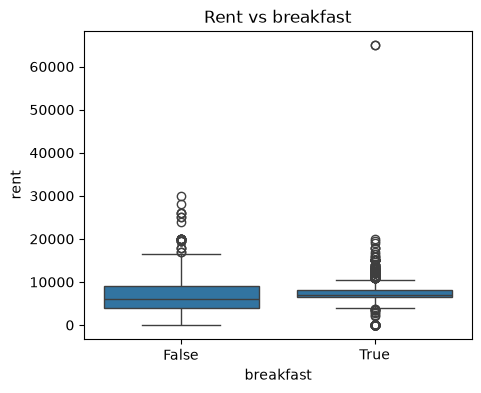

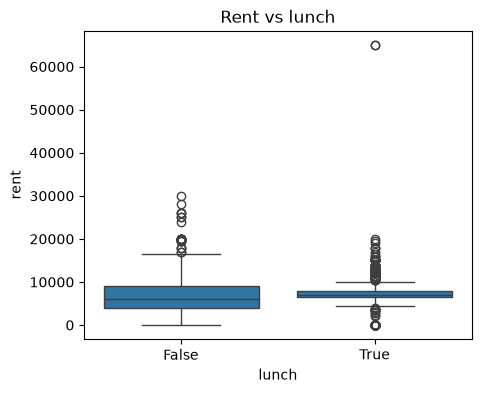

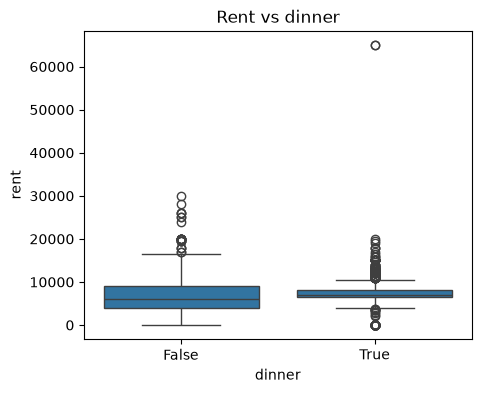

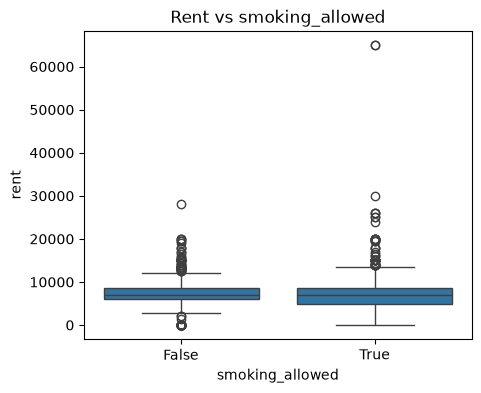

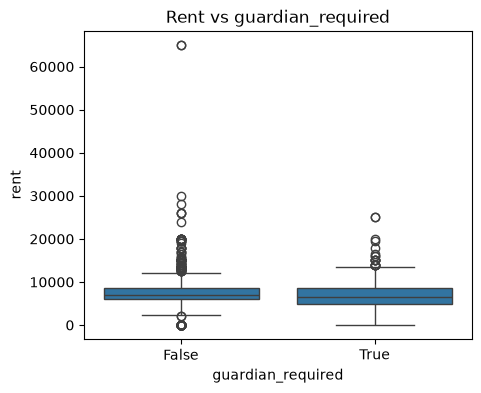

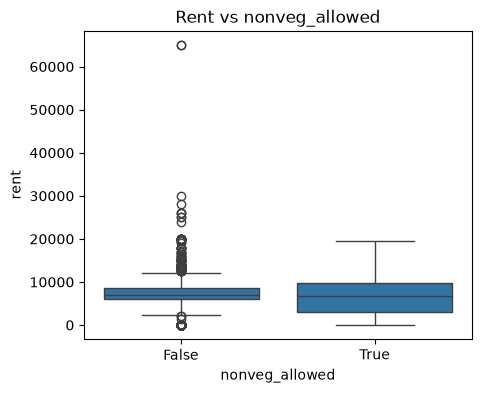

In [49]:
bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(data=df, x=col, y="rent")
    plt.title(f"Rent vs {col}")
    plt.show()